In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import subprocess, sys
pkgs = ["torch", "torchvision", "timm", "scikit-learn", "openpyxl",
        "pandas", "Pillow", "numpy", "tqdm", "matplotlib"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)


0

In [27]:
import os, csv, json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split
import timm
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

# Try importing TPU (torch_xla)
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    TPU_AVAILABLE = True
except:
    TPU_AVAILABLE = False

# Device selection logic
if TPU_AVAILABLE:
    device = xm.xla_device()
    device_name = "TPU"
elif torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = f"GPU – {torch.cuda.get_device_name(0)}"
else:
    device = torch.device("cpu")
    device_name = "CPU"

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device_name}")

PyTorch  : 2.10.0+cpu
Device   : CPU


In [28]:
from pathlib import Path
import torch
import os

class Config:

    # ── Base folder in Google Drive ────────────────────────────────────────
    BASE_PATH = Path("/content/drive/MyDrive/fundusproject")

    # ── File paths ─────────────────────────────────────────────────────────
    EXCEL_PATH = BASE_PATH / "VF_and_clinical_information.xlsx"
    IMAGE_DIR = BASE_PATH / "Annotated images"

    CHECKPOINT_DIR = BASE_PATH / "checkpoints"
    RESULTS_DIR = BASE_PATH / "test_results"

    SHEET_NAME = "Baseline"

    # ── Excel column indices (0-based, after pandas reads header row 1) ────
    COL_AGE = 3        # C – Age
    COL_GENDER = 4     # D – Gender
    COL_IOP = 5        # E – IOP
    COL_CCT = 6        # F – CCT
    COL_CFP = 17       # Q – Fundus image filename

    # Cols G–K (6–10) and R–S (17–18) are intentionally ignored
    COL_VF_START = 20  # T – first VF point
    COL_VF_END = 81    # CB – last VF point → 61 values

    # ── Model dimensions ────────────────────────────────────────────────────
    VIT_MODEL = "vit_base_patch16_224"
    VIT_EMBED_DIM = 768

    CLINICAL_DIM = 4
    MLP_HIDDEN = 128
    MLP_EMBED_DIM = 128

    COND_DIM = VIT_EMBED_DIM + MLP_EMBED_DIM
    VF_DIM = 61

    # ── Diffusion schedule ──────────────────────────────────────────────────
    T_STEPS = 1000
    BETA_START = 5e-5
    BETA_END = 0.01

    # ── Training ────────────────────────────────────────────────────────────
    BATCH_SIZE = 8
    EPOCHS = 200
    LR = 1e-4
    TRAIN_RATIO = 0.70
    RANDOM_SEED = 42

    IMAGE_SIZE = 224
    NUM_WORKERS = 2

    LAMBDA_CONTRAST = 0.1

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()

# Create folders in Google Drive
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)

print("Config ready. Device:", cfg.DEVICE)

Config ready. Device: cpu


In [29]:
class GRAPEDataset(Dataset):
    """
    Parses the GRAPE Baseline sheet.

    Each __getitem__ returns:
    img  : FloatTensor (3, IMAGE_SIZE, IMAGE_SIZE)
    clin : FloatTensor (4,) – z-scored [Age, Gender, IOP, CCT]
    vf   : FloatTensor (61,) – z-scored VF values (target)
    meta : dict {excel_row, cfp_name, raw_clinical, raw_vf}
    """

    GENDER_MAP = {
        "M": 0.0, "Male": 0.0, "male": 0.0, "m": 0.0,
        "F": 1.0, "Female": 1.0, "female": 1.0, "f": 1.0,
    }

    def __init__(self, excel_path: str, image_dir: str):

        self.image_dir = Path(image_dir)

        # Image transform
        self.img_transform = self._build_transform()

        # Parse Excel
        self.records = self._parse_excel(excel_path)

        print(f"[INPUT READING] {len(self.records)} valid samples from '{excel_path}'")

        # Normalisation stats (injected later)
        self.clin_mean = None
        self.clin_std = None
        self.vf_mean = None
        self.vf_std = None


    @staticmethod
    def _build_transform():
        return transforms.Compose([
            transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])


    def _parse_excel(self, excel_path: str) -> list:

        df = pd.read_excel(excel_path, sheet_name=cfg.SHEET_NAME, header=0)

        records = []

        for row_idx, row in df.iterrows():

            vals = row.tolist()

            # Image filename
            cfp = vals[cfg.COL_CFP - 1]

            if pd.isna(cfp) or str(cfp).strip() == "":
                continue

            img_path = self.image_dir / str(cfp).strip()

            if not img_path.exists():
                continue

            # Extract VF values
            vf_raw = vals[cfg.COL_VF_START - 1 : cfg.COL_VF_END - 1]

            if len(vf_raw) < cfg.VF_DIM:
                continue

            vf = []

            for v in vf_raw[:cfg.VF_DIM]:
                try:
                    fv = float(v)
                    vf.append(0.0 if np.isnan(fv) else fv)
                except (TypeError, ValueError):
                    vf.append(0.0)

            # Clinical features
            try:

                age = float(vals[cfg.COL_AGE - 1])

                gender = float(
                    self.GENDER_MAP.get(
                        str(vals[cfg.COL_GENDER - 1]).strip(),
                        0.0
                    )
                )

                iop = float(vals[cfg.COL_IOP - 1])
                cct = float(vals[cfg.COL_CCT - 1])

            except (TypeError, ValueError):
                continue

            records.append({
                "img_path": img_path,
                "cfp_name": str(cfp).strip(),
                "excel_row": row_idx + 2,
                "raw_clinical": np.array([age, gender, iop, cct], dtype=np.float32),
                "raw_vf": np.array(vf, dtype=np.float32),
            })

        return records


    def set_normalisation_stats(self, clin_mean, clin_std, vf_mean, vf_std):

        self.clin_mean = clin_mean.astype(np.float32)
        self.clin_std = clin_std.astype(np.float32)

        self.vf_mean = vf_mean.astype(np.float32)
        self.vf_std = vf_std.astype(np.float32)


    def __len__(self):
        return len(self.records)


    def __getitem__(self, idx):

        rec = self.records[idx]

        # Load image
        img = Image.open(rec["img_path"]).convert("RGB")
        img = self.img_transform(img)

        # Clinical features
        clin = torch.tensor(
            (rec["raw_clinical"] - self.clin_mean) / self.clin_std,
            dtype=torch.float32
        )

        # VF target
        vf = torch.tensor(
            (rec["raw_vf"] - self.vf_mean) / self.vf_std,
            dtype=torch.float32
        )

        return img, clin, vf, rec

In [30]:
def build_splits(dataset: GRAPEDataset):
    """
    70 / 30 split with fixed seed.
    Normalisation stats computed from TRAINING indices only – no leakage.
    """
    all_idx = list(range(len(dataset)))
    train_idx, test_idx = train_test_split(
        all_idx,
        train_size=cfg.TRAIN_RATIO,
        random_state=cfg.RANDOM_SEED,
        shuffle=True,
    )
    print(f"[SPLIT]  Total={len(dataset)}  |  "
          f"Train={len(train_idx)} (70%)  |  Test={len(test_idx)} (30%)")

    # Stats from training only
    tr_clin = np.array([dataset.records[i]["raw_clinical"] for i in train_idx])
    tr_vf   = np.array([dataset.records[i]["raw_vf"]       for i in train_idx])
    clin_mean, clin_std = tr_clin.mean(0), tr_clin.std(0) + 1e-8
    vf_mean,   vf_std   = tr_vf.mean(0),   tr_vf.std(0)   + 1e-8

    dataset.set_normalisation_stats(clin_mean, clin_std, vf_mean, vf_std)
    return (Subset(dataset, train_idx), Subset(dataset, test_idx),
            train_idx, test_idx)


def _collate(batch):
    return (torch.stack([b[0] for b in batch]),
            torch.stack([b[1] for b in batch]),
            torch.stack([b[2] for b in batch]),
            [b[3] for b in batch])


In [31]:
class FundusViTEncoder(nn.Module):
    """
    timm ViT-B/16.  Returns the [CLS] token embedding (768-d).
    Optional: pass fundus_ckpt='RETFound_cfp_weights.pth' for retinal weights.
    Download from: https://github.com/rmaphoh/RETFound_MAE
    """
    def __init__(self, model_name=cfg.VIT_MODEL, pretrained=True, fundus_ckpt=None):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        if fundus_ckpt and os.path.exists(fundus_ckpt):
            state = torch.load(fundus_ckpt, map_location="cpu")
            key   = "model" if "model" in state else "state_dict"
            self.vit.load_state_dict(state.get(key, state), strict=False)
            print(f"[ViT] Loaded fundus checkpoint: {fundus_ckpt}")

    def forward(self, x):
        return self.vit(x)   # (B, 768)

In [32]:
class ClinicalMLP(nn.Module):
    def __init__(self, in_dim=cfg.CLINICAL_DIM, hidden=cfg.MLP_HIDDEN,
                 out_dim=cfg.MLP_EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)   # (B, 128)

In [33]:
class ConditioningFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(cfg.VIT_EMBED_DIM + cfg.MLP_EMBED_DIM, cfg.COND_DIM),
            nn.LayerNorm(cfg.COND_DIM),
            nn.GELU(),
        )
    def forward(self, vit_emb, mlp_emb):
        return self.proj(torch.cat([vit_emb, mlp_emb], dim=-1))   # (B, 896)


In [34]:
class DiffusionSchedule:
    def __init__(self, T=cfg.T_STEPS, beta_start=cfg.BETA_START, beta_end=cfg.BETA_END):
        self.T         = T
        betas          = torch.linspace(beta_start, beta_end, T)
        alphas         = 1.0 - betas
        alpha_bar      = torch.cumprod(alphas, dim=0)
        self.betas     = betas
        self.alphas    = alphas
        self.alpha_bar = alpha_bar
        self.sqrt_ab   = torch.sqrt(alpha_bar)
        self.sqrt_1mab = torch.sqrt(1.0 - alpha_bar)

    def to(self, device):
        for attr in ("betas", "alphas", "alpha_bar", "sqrt_ab", "sqrt_1mab"):
            setattr(self, attr, getattr(self, attr).to(device))
        return self

    def q_sample(self, x0, t, noise=None):
        """Forward diffusion q(x_t|x_0): add noise at step t."""
        if noise is None:
            noise = torch.randn_like(x0)
        s  = self.sqrt_ab[t].unsqueeze(-1)
        sm = self.sqrt_1mab[t].unsqueeze(-1)
        return s * x0 + sm * noise, noise

In [35]:
class SinusoidalTimeEmbed(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(-np.log(10000) *
                         torch.arange(half, device=t.device) / (half - 1))
        args = t.float().unsqueeze(-1) * freq.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock1D(nn.Module):
    """Residual block conditioned on time + conditioning vector."""
    def __init__(self, channels, time_dim, cond_dim):
        super().__init__()
        self.norm1     = nn.LayerNorm(channels)
        self.fc1       = nn.Linear(channels, channels)
        self.norm2     = nn.LayerNorm(channels)
        self.fc2       = nn.Linear(channels, channels)
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, channels))
        self.cond_proj = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, channels))

    def forward(self, x, t_emb, cond):
        h = self.fc1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb) + self.cond_proj(cond)
        h = self.fc2(F.silu(self.norm2(h)))
        return x + h


class VFDenoiser(nn.Module):
    """
    Predicts noise ε at step t.
    Input  : (B,61) x_t  +  (B,) t  +  (B,896) cond
    Output : (B,61) predicted noise
    """
    def __init__(self, vf_dim=cfg.VF_DIM, cond_dim=cfg.COND_DIM,
                 hidden=256, depth=6, time_dim=128):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbed(time_dim),
            nn.Linear(time_dim, time_dim * 4), nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )
        self.input_proj  = nn.Linear(vf_dim, hidden)
        self.blocks      = nn.ModuleList(
            [ResBlock1D(hidden, time_dim, cond_dim) for _ in range(depth)])
        self.output_proj = nn.Sequential(
            nn.LayerNorm(hidden), nn.Linear(hidden, vf_dim))

    def forward(self, x_t, t, cond):
        t_emb = self.time_embed(t)
        h     = self.input_proj(x_t)
        for block in self.blocks:
            h = block(h, t_emb, cond)
        return self.output_proj(h)


In [36]:
class CDPMVFSynthesizer(nn.Module):
    def __init__(self, fundus_ckpt=None):
        super().__init__()
        self.vit      = FundusViTEncoder(fundus_ckpt=fundus_ckpt)
        self.mlp      = ClinicalMLP()
        self.fusion   = ConditioningFusion()
        self.denoiser = VFDenoiser()

    def encode(self, images, clinical):
        """Fuse fundus image + clinical embeddings → conditioning vector (B,896)."""
        return self.fusion(self.vit(images), self.mlp(clinical))

    def forward(self, images, clinical, x_t, t):
        """Predict noise ε added at diffusion step t."""
        return self.denoiser(x_t, t, self.encode(images, clinical))

# Quick parameter count
_m = CDPMVFSynthesizer()
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
del _m


Trainable parameters: 89,173,693


In [37]:
checkpoint = torch.load(
    "/content/drive/MyDrive/fundusproject/checkpoints/best_model.pt",
    map_location="cpu",
    weights_only=False   #
)

In [38]:
model = CDPMVFSynthesizer()

In [39]:
model.load_state_dict(checkpoint["model_state"])

<All keys matched successfully>

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [41]:
model.eval()

CDPMVFSynthesizer(
  (vit): FundusViTEncoder(
    (vit): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
     

In [42]:
@torch.no_grad()
def ddpm_reverse_sample(model, schedule, cond, device, n_steps=300):
    """
    Full DDPM reverse chain: x_T ~ N(0,I)  →  x_0  (synthesised VF, z-score space).

    Parameters
    ----------
    cond    : (B, COND_DIM)  conditioning vector from model.encode()
    Returns : (B, VF_DIM)   synthesised VF, still z-scored
    """
    x = torch.randn(cond.size(0), cfg.VF_DIM, device=device)

    for t_idx in tqdm(reversed(range(n_steps)),
                      desc="DDPM reverse sampling", total=n_steps, leave=False):
        t_tensor = torch.full((cond.size(0),), t_idx, device=device, dtype=torch.long)
        pred_eps = model.denoiser(x, t_tensor, cond)

        beta_t         = schedule.betas[t_idx]
        alpha_t        = schedule.alphas[t_idx]
        alpha_bar_t    = schedule.alpha_bar[t_idx]
        alpha_bar_prev = (schedule.alpha_bar[t_idx - 1] if t_idx > 0
                          else torch.tensor(1.0, device=device))

        # Estimate clean x_0
        x0_pred = (x - torch.sqrt(1.0 - alpha_bar_t) * pred_eps) / torch.sqrt(alpha_bar_t)
        x0_pred = x0_pred.clamp(-3.0, 3.0)

        # Posterior mean
        coef1 = torch.sqrt(alpha_bar_prev) * beta_t / (1.0 - alpha_bar_t)
        coef2 = torch.sqrt(alpha_t) * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
        mean  = coef1 * x0_pred + coef2 * x

        if t_idx > 0:
            var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
            x   = mean + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = mean

    return x


In [43]:
def run_test():

    device    = torch.device(cfg.DEVICE)
    ckpt_path = Path(cfg.CHECKPOINT_DIR) / "best_model.pt"
    assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}. Run Section 4 first."

    # 5.1 – Load checkpoint
    print(f"Loading checkpoint: {ckpt_path}")

    ckpt = torch.load(
        ckpt_path,
        map_location=device,
        weights_only=False   # FIX for PyTorch ≥2.6
    )

    model = CDPMVFSynthesizer().to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    schedule = DiffusionSchedule().to(device)

    vf_mean   = np.array(ckpt["vf_mean"],   dtype=np.float32)
    vf_std    = np.array(ckpt["vf_std"],    dtype=np.float32)
    clin_mean = np.array(ckpt["clin_mean"], dtype=np.float32)
    clin_std  = np.array(ckpt["clin_std"],  dtype=np.float32)

    # 5.2 – Reconstruct 30 % test split
    dataset = GRAPEDataset(cfg.EXCEL_PATH, cfg.IMAGE_DIR)
    dataset.set_normalisation_stats(clin_mean, clin_std, vf_mean, vf_std)

    idx_path = Path(cfg.CHECKPOINT_DIR) / "test_indices.npy"

    if idx_path.exists():
        test_idx = np.load(idx_path).tolist()
    else:
        _, _, _, test_idx = build_splits(dataset)

    print(f"Test set: {len(test_idx)} samples")

    test_dl = DataLoader(
        Subset(dataset, test_idx),
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        collate_fn=_collate
    )

    vf_mean_t = torch.tensor(vf_mean, device=device)
    vf_std_t  = torch.tensor(vf_std,  device=device)

    all_pred, all_true, all_meta = [], [], []

    # 5.3 – Synthesise VFs
    with torch.no_grad():

        for b_idx, (imgs, clin, vf_norm, metas) in enumerate(test_dl):

            imgs, clin = imgs.to(device), clin.to(device)
            vf_norm    = vf_norm.to(device)

            lo = b_idx * cfg.BATCH_SIZE + 1
            hi = min((b_idx + 1) * cfg.BATCH_SIZE, len(test_idx))

            print(f"Batch {b_idx+1}/{len(test_dl)}  (samples {lo}-{hi})")

            # Encode fundus + clinical features
            cond = model.encode(imgs, clin)

            # DDPM reverse sampling
            synth_norm = ddpm_reverse_sample(
                model,
                schedule,
                cond,
                device
            )

            # 5.4 – Denormalise VF
            synth = (synth_norm * vf_std_t + vf_mean_t).cpu().numpy()
            true  = (vf_norm    * vf_std_t + vf_mean_t).cpu().numpy()

            all_pred.append(synth)
            all_true.append(true)
            all_meta.extend(metas)

    all_pred = np.concatenate(all_pred, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    # 5.5 – Metrics
    results = []

    for i in range(len(all_meta)):

        pred = all_pred[i]
        true = all_true[i]

        mse  = float(np.mean((pred - true) ** 2))
        mae  = float(np.mean(np.abs(pred - true)))
        rmse = float(np.sqrt(mse))

        if true.std() > 1e-6 and pred.std() > 1e-6:
            r = float(np.corrcoef(true, pred)[0, 1])
        else:
            r = float("nan")

        row = {
            "sample_idx": i,
            "excel_row":  all_meta[i]["excel_row"],
            "image_file": all_meta[i]["cfp_name"],
            "mse":  round(mse, 6),
            "mae":  round(mae, 6),
            "rmse": round(rmse, 6),
            "pearson_r": round(r, 6) if not np.isnan(r) else "nan",
        }

        for j in range(cfg.VF_DIM):
            row[f"true_vf_{j+1}"]  = round(float(true[j]), 4)
            row[f"synth_vf_{j+1}"] = round(float(pred[j]), 4)

        results.append(row)

    # 5.6 – Save CSV
    csv_path = Path(cfg.RESULTS_DIR) / "test_synthesis_results.csv"

    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(results[0].keys()))
        w.writeheader()
        w.writerows(results)

    print(f"CSV saved → {csv_path}")

    # 5.7 – Summary
    mses  = [r["mse"] for r in results]
    maes  = [r["mae"] for r in results]
    rmses = [r["rmse"] for r in results]

    rs = [float(r["pearson_r"]) for r in results if r["pearson_r"] != "nan"]

    print(f"\n{'─'*50}")
    print(f"TEST SUMMARY ({len(results)} samples)")
    print(f"{'─'*50}")
    print(f"MSE       : {np.mean(mses):.4f} ± {np.std(mses):.4f}")
    print(f"MAE       : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    print(f"RMSE      : {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"Pearson-r : {np.mean(rs):.4f} ± {np.std(rs):.4f}")
    print(f"{'─'*50}")

    return all_true, all_pred, results

In [44]:
all_true, all_pred, results = run_test()

Loading checkpoint: /content/drive/MyDrive/fundusproject/checkpoints/best_model.pt
[INPUT READING] 263 valid samples from '/content/drive/MyDrive/fundusproject/VF_and_clinical_information.xlsx'
Test set: 79 samples
Batch 1/10  (samples 1-8)


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Batch 2/10  (samples 9-16)


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Batch 3/10  (samples 17-24)


...

Batch 9/10  (samples 65-72)


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Batch 10/10  (samples 73-79)


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

CSV saved → /content/drive/MyDrive/fundusproject/test_results/test_synthesis_results.csv

──────────────────────────────────────────────────
TEST SUMMARY (79 samples)
──────────────────────────────────────────────────
MSE       : 71.7631 ± 70.9818
MAE       : 6.2579 ± 3.0393
RMSE      : 7.7660 ± 3.3842
Pearson-r : 0.5808 ± 0.1951
──────────────────────────────────────────────────


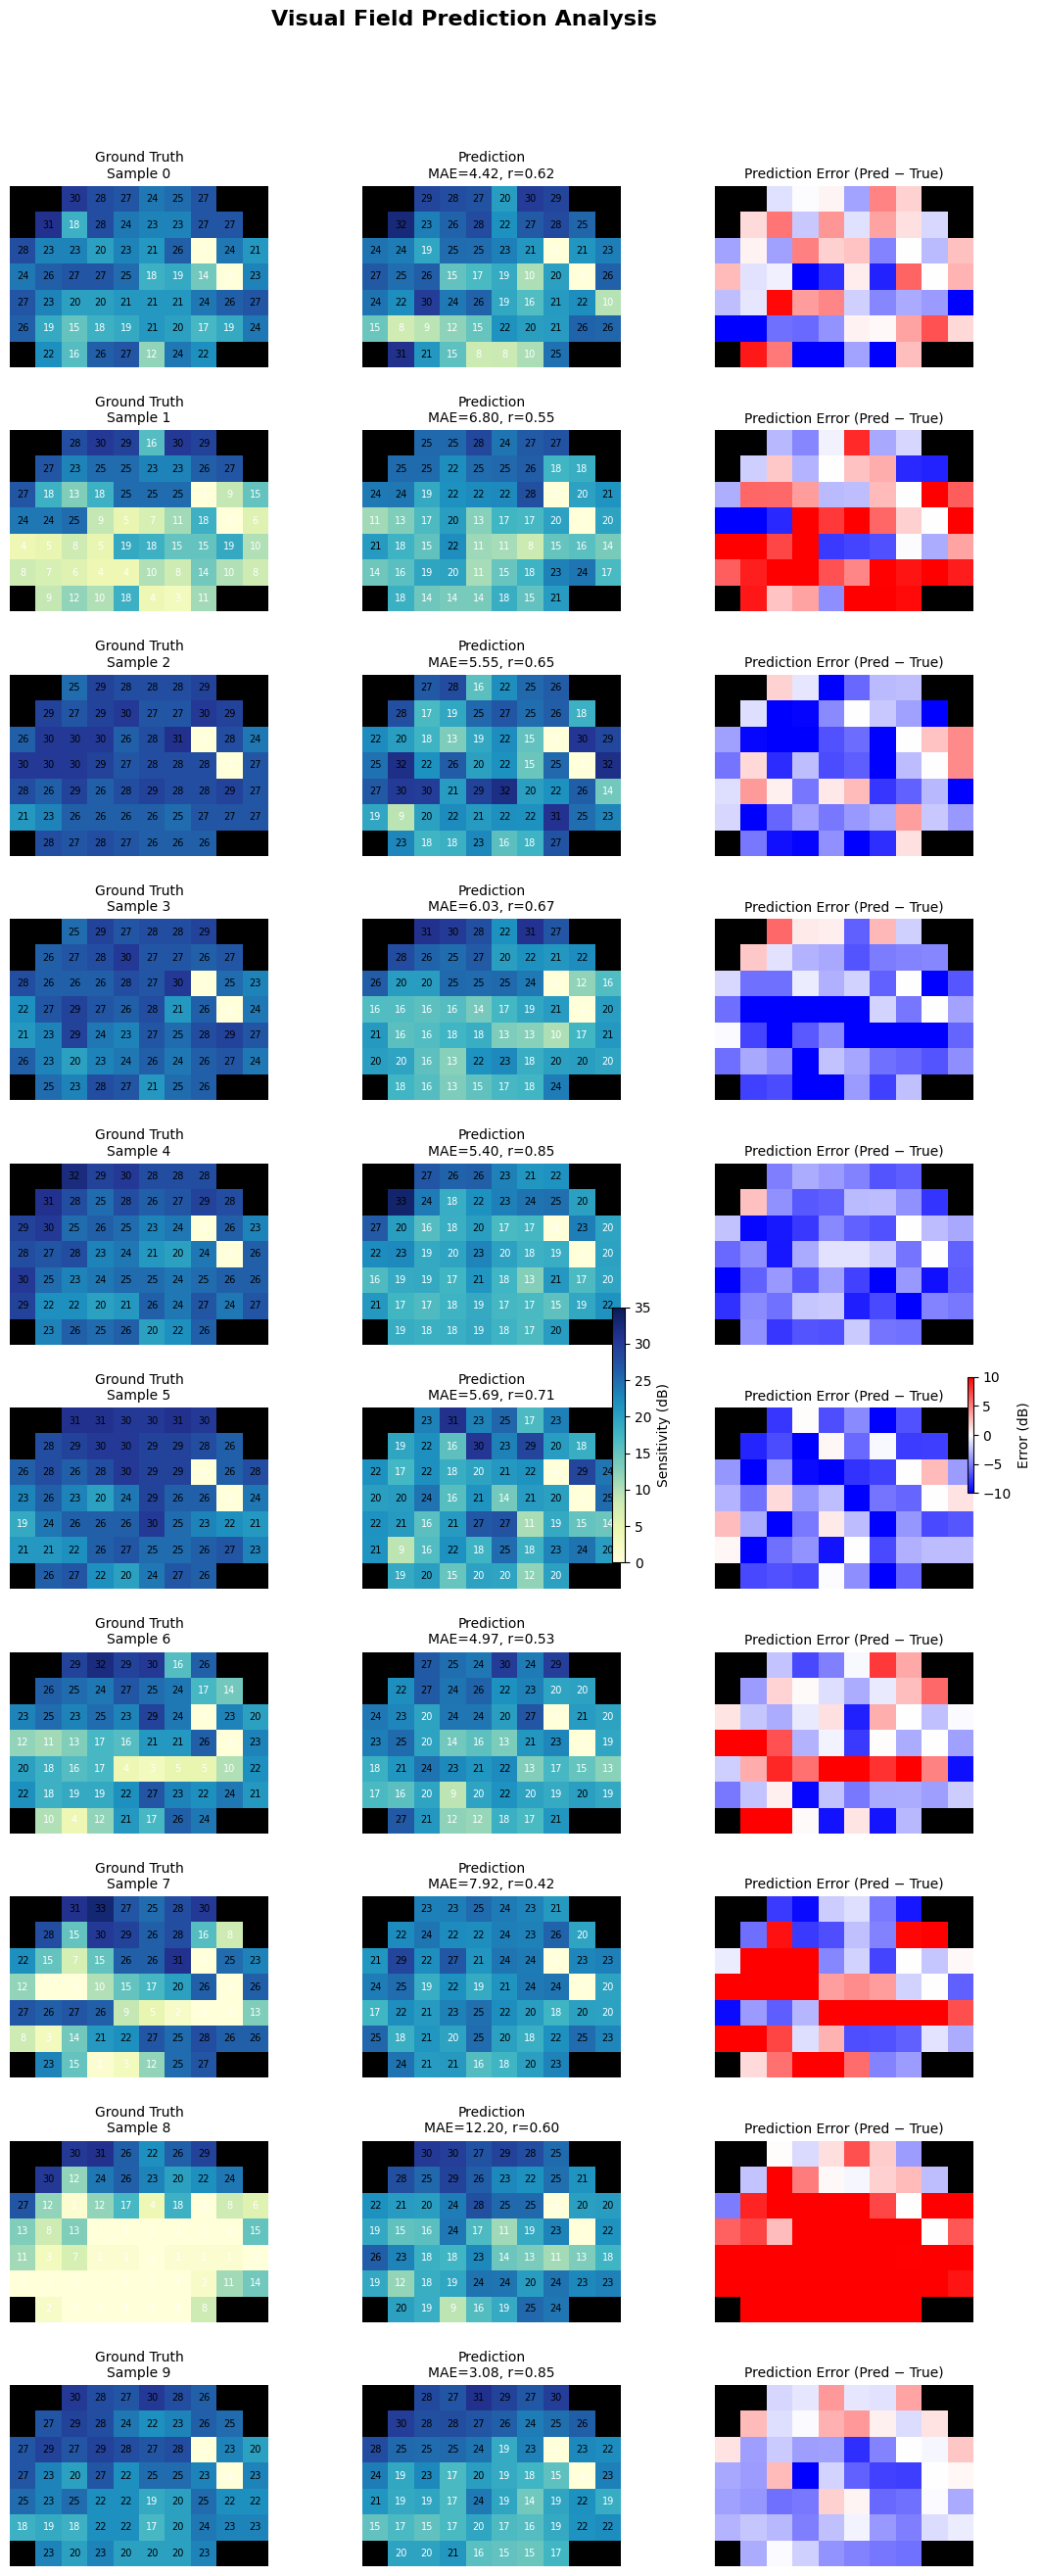

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# VF grid layout
vf_grid = np.array([
    [np.nan,np.nan,0,1,2,3,4,5,np.nan,np.nan],
    [np.nan,6,7,8,9,10,11,12,13,np.nan],
    [14,15,16,17,18,19,20,21,22,23],
    [24,25,26,27,28,29,30,31,32,33],
    [34,35,36,37,38,39,40,41,42,43],
    [44,45,46,47,48,49,50,51,52,53],
    [np.nan,54,55,56,57,58,59,60,np.nan,np.nan]
])

vf_grid_int = np.nan_to_num(vf_grid, nan=-1).astype(int)

n_show = min(10, len(all_true))

if n_show == 0:
    raise ValueError("No predictions available. Run run_test() first.")

fig, axes = plt.subplots(n_show, 3, figsize=(13, 3*n_show))

if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

# colormaps
cmap_vf = plt.cm.YlGnBu.copy()
cmap_vf.set_bad(color='black')

cmap_err = plt.cm.bwr.copy()
cmap_err.set_bad(color='black')

for row in range(n_show):

    true_vf = np.full(vf_grid.shape, np.nan)
    pred_vf = np.full(vf_grid.shape, np.nan)
    err_vf  = np.full(vf_grid.shape, np.nan)

    for i in range(cfg.VF_DIM):
        loc = np.where(vf_grid_int == i)

        true_vf[loc] = all_true[row][i]
        pred_vf[loc] = all_pred[row][i]
        err_vf[loc]  = all_pred[row][i] - all_true[row][i]

    # ---------------- Ground Truth ----------------
    im1 = axes[row,0].imshow(true_vf, cmap=cmap_vf, vmin=0, vmax=35)
    axes[row,0].set_title(f"Ground Truth\nSample {row}", fontsize=10)

    for y in range(true_vf.shape[0]):
        for x in range(true_vf.shape[1]):

            if not np.isnan(true_vf[y,x]):

                color = "white" if true_vf[y,x] < 20 else "black"

                axes[row,0].text(
                    x, y,
                    f"{true_vf[y,x]:.0f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=color
                )

    # ---------------- Prediction ----------------
    im2 = axes[row,1].imshow(pred_vf, cmap=cmap_vf, vmin=0, vmax=35)

    axes[row,1].set_title(
        f"Prediction\nMAE={results[row]['mae']:.2f}, r={results[row]['pearson_r']:.2f}",
        fontsize=10
    )

    for y in range(pred_vf.shape[0]):
        for x in range(pred_vf.shape[1]):

            if not np.isnan(pred_vf[y,x]):

                color = "white" if pred_vf[y,x] < 20 else "black"

                axes[row,1].text(
                    x, y,
                    f"{pred_vf[y,x]:.0f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=color
                )

    # ---------------- Error Map ----------------
    im3 = axes[row,2].imshow(err_vf, cmap=cmap_err, vmin=-10, vmax=10)
    axes[row,2].set_title("Prediction Error (Pred − True)", fontsize=10)

    for ax in axes[row]:
        ax.axis("off")

# colorbars
cbar1 = fig.colorbar(im2, ax=axes[:,0:2], fraction=0.02, pad=0.02)
cbar1.set_label("Sensitivity (dB)")

cbar2 = fig.colorbar(im3, ax=axes[:,2], fraction=0.02, pad=0.02)
cbar2.set_label("Error (dB)")

plt.suptitle("Visual Field Prediction Analysis", fontsize=16, fontweight="bold")

plt.subplots_adjust(top=0.92, wspace=0.25, hspace=0.35)

plt.savefig(Path(cfg.RESULTS_DIR) / "vf_prediction_analysis.png", dpi=200)

plt.show()

In [46]:
INFER_IMAGE  = str(cfg.IMAGE_DIR / "1_OD_1.jpg")
INFER_AGE    = 46.0
INFER_GENDER = "F"
INFER_IOP    = 14.7
INFER_CCT    = 535.0

In [47]:
def infer_single(image_path, age, gender, iop, cct, ckpt_path=None):
    print(" Function started")

    device = torch.device(cfg.DEVICE)
    ckpt_path = ckpt_path or str(Path(cfg.CHECKPOINT_DIR) / "best_model.pt")

    print(" Loading checkpoint...")
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    print(" Loading model...")
    model = CDPMVFSynthesizer().to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    print(" Loading schedule...")
    schedule = DiffusionSchedule().to(device)

    #  OPTIONAL: speed up for testing
    if hasattr(schedule, "T"):
        schedule.T = 50   # reduce from 1000 → FAST

    vf_mean   = np.array(ckpt["vf_mean"], dtype=np.float32)
    vf_std    = np.array(ckpt["vf_std"], dtype=np.float32)
    clin_mean = np.array(ckpt["clin_mean"], dtype=np.float32)
    clin_std  = np.array(ckpt["clin_std"], dtype=np.float32)

    print(" Loading image...")
    tfm = transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])

    img = Image.open(image_path).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title("Input Fundus Image")
    axes[0].axis("off")

    img_t = tfm(img).unsqueeze(0).to(device)

    print(" Processing clinical data...")
    gender_val = 1.0 if str(gender).upper().startswith("F") else 0.0
    clin_raw   = np.array([age, gender_val, iop, cct], dtype=np.float32)

    clin_t = torch.tensor(
        (clin_raw - clin_mean) / clin_std,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    print(" Running diffusion...")
    with torch.no_grad():
        cond = model.encode(img_t, clin_t)
        synth_norm = ddpm_reverse_sample(model, schedule, cond, device)

    print("Inference done")

    synth_vf = synth_norm.cpu().numpy().squeeze() * vf_std + vf_mean

    print(" Output shape:", synth_vf.shape)
    print("\nSynthesised Visual Field (61 points):")
    for i, v in enumerate(synth_vf):
        print(f"VF[{i+1:02d}] = {v:.3f}")

    # Plot
    axes[1].bar(np.arange(1, cfg.VF_DIM + 1), synth_vf)
    axes[1].set_title("Synthesised VF")
    plt.tight_layout()
    plt.show()

    return synth_vf

 Function started
 Loading checkpoint...
 Loading model...
 Loading schedule...
 Loading image...
 Processing clinical data...
 Running diffusion...


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Inference done
 Output shape: (61,)

Synthesised Visual Field (61 points):
VF[01] = 30.062
VF[02] = 25.830
VF[03] = 28.320
VF[04] = 31.955
VF[05] = 26.608
VF[06] = 24.917
VF[07] = 26.196
VF[08] = 27.884
VF[09] = 23.829
VF[10] = 25.694
VF[11] = 23.851
VF[12] = 23.411
VF[13] = 26.041
VF[14] = 28.073
VF[15] = 20.661
VF[16] = 30.140
VF[17] = 17.747
VF[18] = 25.938
VF[19] = 27.415
VF[20] = 20.204
VF[21] = 27.092
VF[22] = -1.000
VF[23] = 18.292
VF[24] = 20.277
VF[25] = 23.405
VF[26] = 22.185
VF[27] = 28.394
VF[28] = 23.767
VF[29] = 12.904
VF[30] = 22.139
VF[31] = 24.841
VF[32] = 19.368
VF[33] = -1.000
VF[34] = 21.439
VF[35] = 21.317
VF[36] = 18.988
VF[37] = 18.402
VF[38] = 17.559
VF[39] = 18.264
VF[40] = 14.335
VF[41] = 18.280
VF[42] = 17.269
VF[43] = 21.660
VF[44] = 14.114
VF[45] = 19.114
VF[46] = 18.105
VF[47] = 14.755
VF[48] = 17.444
VF[49] = 17.984
VF[50] = 18.335
VF[51] = 17.301
VF[52] = 20.580
VF[53] = 20.584
VF[54] = 21.082
VF[55] = 16.405
VF[56] = 24.393
VF[57] = 21.433
VF[58] = 13.8

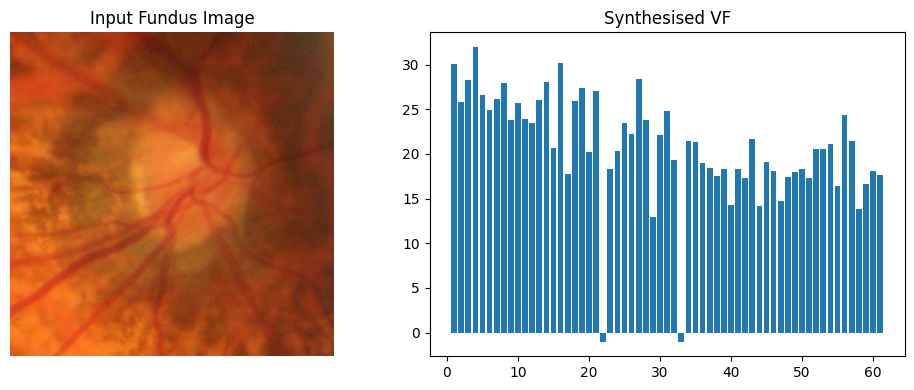

In [48]:
    synth_vf = infer_single(
    INFER_IMAGE,
    INFER_AGE,
    INFER_GENDER,
    INFER_IOP,
    INFER_CCT
    )

In [49]:
def vf_to_grid(vf):
    grid = np.full((10, 10), np.nan)

    # Standard approximate mapping (Humphrey 24-2 style)
    indices = [
        (0,3),(0,4),(0,5),(0,6),
        (1,2),(1,3),(1,4),(1,5),(1,6),(1,7),
        (2,1),(2,2),(2,3),(2,4),(2,5),(2,6),(2,7),(2,8),
        (3,1),(3,2),(3,3),(3,4),(3,5),(3,6),(3,7),(3,8),
        (4,1),(4,2),(4,3),(4,4),(4,5),(4,6),(4,7),(4,8),
        (5,1),(5,2),(5,3),(5,4),(5,5),(5,6),(5,7),(5,8),
        (6,1),(6,2),(6,3),(6,4),(6,5),(6,6),(6,7),(6,8),
        (7,2),(7,3),(7,4),(7,5),(7,6),(7,7),
        (8,3),(8,4),(8,5),(8,6)
    ]

    for i, (r,c) in enumerate(indices):
        if i < len(vf):
            grid[r,c] = vf[i]

    return grid

In [50]:
import matplotlib.pyplot as plt

def plot_vf_heatmap(vf):
    grid = vf_to_grid(vf)

    plt.figure(figsize=(6,6))
    plt.imshow(grid, cmap='jet', interpolation='nearest')
    plt.colorbar(label="Sensitivity (dB)")
    plt.title("Visual Field Heatmap")
    plt.axis("off")
    plt.show()

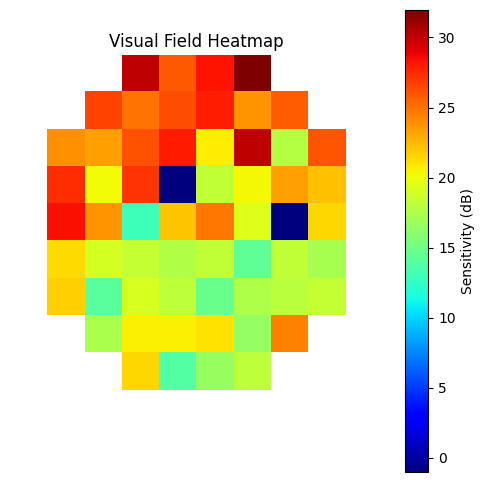

In [51]:
plot_vf_heatmap(synth_vf)